# Streamflow Forecasting Using LSTM

## Sample Dataset Experiment

### Objective
The objective of this experiment is to learn and implement a Long Short-Term Memory (LSTM) neural network for one-step-ahead streamflow forecasting.

Historical hydrological observations will be used to predict streamflow at the next time step.

### Workflow
1. Load the hydrological dataset
2. Explore and visualize the data
3. Preprocess the time series
4. Create input sequences
5. Split the data chronologically
6. Build the LSTM model
7. Train the model
8. Predict streamflow
9. Evaluate the predictions
10. Compare observed and predicted streamflow

### Evaluation Metrics
- RMSE — Root Mean Squared Error
- MAE — Mean Absolute Error
- R² — Coefficient of Determination
- NSE — Nash-Sutcliffe Efficiency


## 1. Import Required Libraries

We first import the Python libraries required for data processing,
visualization, machine learning, and construction of the LSTM model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf


Sequential = tf.keras.Sequential
LSTM = tf.keras.layers.LSTM
Dense = tf.keras.layers.Dense
LSTM = tf.keras.layers.LSTM
Dense = tf.keras.layers.Dense

Bidirectional = tf.keras.layers.Bidirectional
MultiHeadAttention = tf.keras.layers.MultiHeadAttention
LayerNormalization = tf.keras.layers.LayerNormalization
Dropout = tf.keras.layers.Dropout
GlobalAveragePooling1D = tf.keras.layers.GlobalAveragePooling1D
Input = tf.keras.layers.Input

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Sample Dataset

For the sample experiment, a publicly available daily streamflow dataset
will be used.

The purpose of this dataset is to understand the complete time-series
forecasting workflow before applying the same methodology to the
Kantamal catchment.

The model will use previous streamflow observations to predict the
streamflow at the next time step.

### Why use a sample dataset first?

Before working with the Kantamal catchment, it is useful to validate the
LSTM workflow on a clean and well-structured time series.

This helps us understand:

- chronological train-test splitting
- normalization
- sliding-window sequence generation
- LSTM input structure
- model training
- prediction
- performance evaluation

## 3. Load and Inspect the Streamflow Dataset

The sample dataset contains daily discharge observations from USGS station
01646500 (Potomac River near Washington, D.C.).

The target variable is streamflow (discharge), represented by parameter
code 00060 and measured in cubic feet per second (ft³/s).

The raw dataset is first inspected before preprocessing.

In [2]:
file_path = "../data/sample/2026-09-25T10-17-13.234Z-daily.csv"

df = pd.read_csv(file_path)

df.head()

,id,approval_status,last_modified,monitoring_location_id,parameter_code,qualifier,statistic_id,time,time_series_id,unit_of_measure,value,x,y
0,26fb66a3-4cd2-4309-b792-a0b4f5e19b9f,Approved,2025-03-11T06:29:47.694332+00:00,USGS-01646500,60,NaN,3,1930-03-01,2cf409b0d9694c01828f5d4ff14586a5,ft^3/s,9500,-77.127639,38.949778
1,ab9b1e1b-210b-411d-a91d-cbc4469cf32e,Approved,2025-03-11T06:29:47.694332+00:00,USGS-01646500,60,NaN,3,1930-03-02,2cf409b0d9694c01828f5d4ff14586a5,ft^3/s,9200,-77.127639,38.949778
2,0662afe3-fc1d-4537-a0de-ec7bfdf9bbe5,Approved,2025-03-11T06:29:47.694332+00:00,USGS-01646500,60,NaN,3,1930-03-03,2cf409b0d9694c01828f5d4ff14586a5,ft^3/s,8500,-77.127639,38.949778
3,0ca5e5fe-3238-48b4-a6b8-2aee5738c4ae,Approved,2025-03-11T06:29:47.694332+00:00,USGS-01646500,60,NaN,3,1930-03-04,2cf409b0d9694c01828f5d4ff14586a5,ft^3/s,8000,-77.127639,38.949778
4,1da76b31-60b1-476c-b0c8-2da94228250c,Approved,2025-03-11T06:29:47.694332+00:00,USGS-01646500,60,NaN,3,1930-03-05,2cf409b0d9694c01828f5d4ff14586a5,ft^3/s,7500,-77.127639,38.949778


In [3]:
print("Dataset shape:", df.shape)
print("Start date:", df["time"].min())
print("End date:", df["time"].max())

print("\nStation:")
print(df["monitoring_location_id"].unique())

print("\nUnit:")
print(df["unit_of_measure"].unique())

Dataset shape: (33179, 13)
Start date: 1930-03-01
End date: 2020-12-31

Station:
<StringArray>
['USGS-01646500']
Length: 1, dtype: str

Unit:
<StringArray>
['ft^3/s']
Length: 1, dtype: str


In [4]:
df[["time", "value"]].isnull().sum()

time     0
value    0
dtype: int64

## 4. Prepare the Streamflow Time Series

For the initial univariate forecasting experiment, only the observation
date and daily streamflow are required.

A study period from 2000 to 2020 is selected. The original raw dataset
is preserved unchanged.

In [5]:
streamflow = df[["time", "value"]].copy()

streamflow["time"] = pd.to_datetime(streamflow["time"])

streamflow = streamflow[
    (streamflow["time"] >= "2000-01-01") &
    (streamflow["time"] <= "2020-12-31")
].copy()

streamflow = streamflow.sort_values("time")

streamflow = streamflow.rename(
    columns={
        "time": "Date",
        "value": "Streamflow"
    }
)

streamflow.reset_index(drop=True, inplace=True)

streamflow.head()

,Date,Streamflow
0,2000-01-01,5250
1,2000-01-02,5030
2,2000-01-03,4850
3,2000-01-04,4900
4,2000-01-05,5260


In [6]:
print("Number of observations:", len(streamflow))
print("Start:", streamflow["Date"].min())
print("End:", streamflow["Date"].max())

streamflow.describe()

Number of observations: 7671
Start: 2000-01-01 00:00:00
End: 2020-12-31 00:00:00


,Date,Streamflow
count,7671,7671.000000
mean,2010-07-02 00:00:00,12053.579716
min,2000-01-01 00:00:00,258.000000
25%,2005-04-01 12:00:00,3290.000000
50%,2010-07-02 00:00:00,7240.000000
75%,2015-10-01 12:00:00,14500.000000
max,2020-12-31 00:00:00,192000.000000
std,NaN,15219.905008


## 5. Visualize Daily Streamflow

The daily streamflow time series is visualized to examine temporal
variability, seasonal behaviour, and extreme-flow events before model
development.

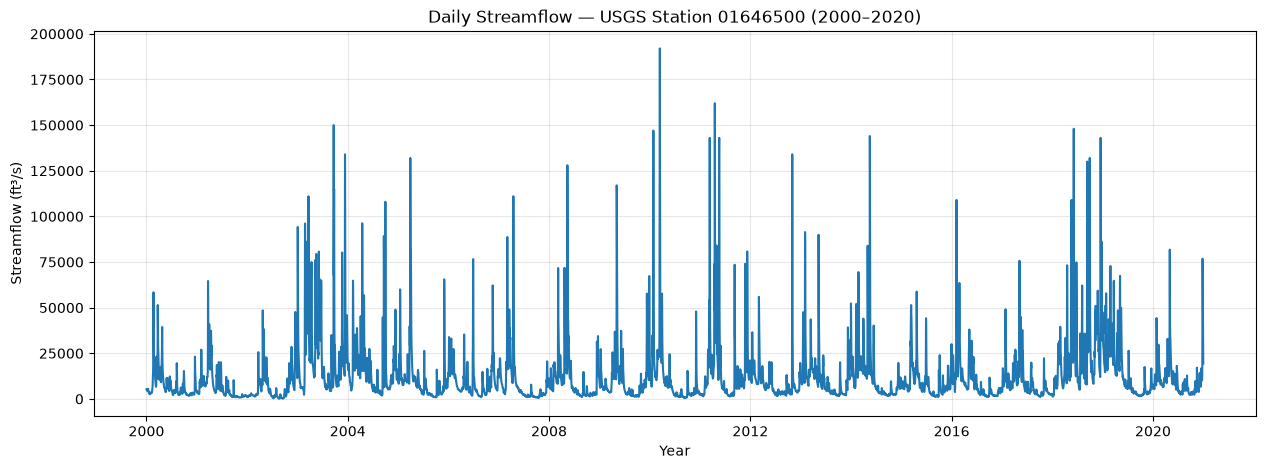

In [7]:
plt.figure(figsize=(15, 5))

plt.plot(
    streamflow["Date"],
    streamflow["Streamflow"]
)

plt.title("Daily Streamflow — USGS Station 01646500 (2000–2020)")
plt.xlabel("Year")
plt.ylabel("Streamflow (ft³/s)")
plt.grid(alpha=0.3)

plt.show()

## 6. Chronological Train-Validation-Test Split

Because streamflow forecasting is a time-series problem, the observations
must preserve their temporal order.

The dataset is therefore divided chronologically into:

- 70% training data
- 15% validation data
- 15% testing data

Random shuffling is avoided to prevent future observations from leaking
into model training.

In [8]:
values = streamflow["Streamflow"].to_numpy(dtype=float).reshape(-1, 1)

n = len(values)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = values[:train_end]
val_data = values[train_end:val_end]
test_data = values[val_end:]

print("Total observations:", n)
print("Training observations:", len(train_data))
print("Validation observations:", len(val_data))
print("Testing observations:", len(test_data))

Total observations: 7671
Training observations: 5369
Validation observations: 1151
Testing observations: 1151


## 7. Normalize Streamflow

Min-Max normalization is applied so that streamflow values are scaled
to a range between 0 and 1.

The scaler is fitted only on the training data to avoid data leakage
from the validation and test periods.

In [9]:
scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

print("Training minimum:", train_scaled.min())
print("Training maximum:", train_scaled.max())

Training minimum: 0.0
Training maximum: 0.9999999999999999


## 8. Create Sliding-Window Sequences

A 30-day lookback window is used.

For each training sample, the previous 30 days of streamflow are used
as input and the model learns to predict the streamflow of the next day. 

In [10]:
SEQUENCE_LENGTH = 30

def create_sequences(data, sequence_length):
    X = []
    y = []

    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [11]:
X_train, y_train = create_sequences(
    train_scaled,
    SEQUENCE_LENGTH
)

X_val, y_val = create_sequences(
    val_scaled,
    SEQUENCE_LENGTH
)

X_test, y_test = create_sequences(
    test_scaled,
    SEQUENCE_LENGTH
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (5339, 30, 1)
y_train: (5339, 1)
X_val: (1121, 30, 1)
y_val: (1121, 1)
X_test: (1121, 30, 1)
y_test: (1121, 1)


## 9. Build the LSTM Model

An LSTM neural network is created for one-step-ahead streamflow forecasting.

The model receives 30 previous daily streamflow values and predicts the
streamflow for the next day.

In [12]:
model = Sequential([
    LSTM(
        units=64,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),
    Dense(1)
])

model.summary()

c:\Users\karthik\Documents\kantamal-streamflow-forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

## 10. Compile the Model

The model is compiled using the Adam optimizer and Mean Squared Error (MSE)
as the loss function.

The optimizer updates the neural-network weights during training, while
the loss function measures the difference between predicted and observed
streamflow.

In [13]:
model.compile(
    optimizer="adam",
    loss="mse"
)

## 11. Train the LSTM Model

The LSTM model is trained using the chronological training sequences.

The validation dataset is evaluated after every epoch to monitor the
model's performance on unseen data.

The temporal order of observations is preserved by disabling shuffling
during training.

In [14]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    shuffle=False,
    verbose=1
)

Epoch 1/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0042 - val_loss: 0.0013
Epoch 2/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0029 - val_loss: 9.6710e-04
Epoch 3/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0022 - val_loss: 7.4586e-04
Epoch 4/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0018 - val_loss: 5.8895e-04
Epoch 5/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0015 - val_loss: 5.6398e-04
Epoch 6/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0013 - val_loss: 4.0818e-04
Epoch 7/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0012 - val_loss: 4.1237e-04
Epoch 8/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0011 - val_loss: 4.1036e-04
Epoch 9/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0011 - val_loss: 4.0025e-04
Epoch 10/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0011 - val_loss: 3.8750e-04
Epoch 11/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0010 - val_loss: 3.7570e-04
Epoch 

## 12. Training and Validation Loss

The training and validation loss are visualized across epochs to examine
the learning behaviour of the LSTM model.

A decreasing validation loss indicates that the model is improving its
performance on unseen validation data.

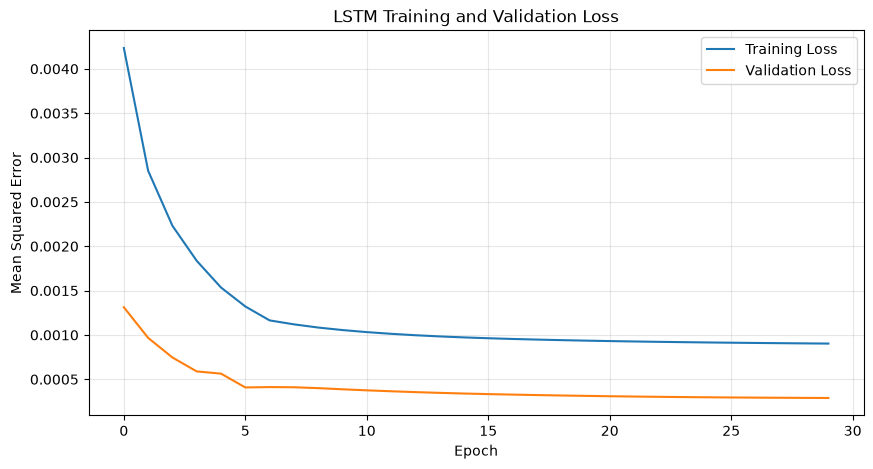

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

TRAIN → learned from it
VALIDATION → helped us monitor training
TEST → untouched so far

## 13. Generate Test Predictions

The trained LSTM model is applied to the unseen test dataset.

The predicted and observed values are transformed back from normalized
values to their original streamflow units (ft³/s) before evaluation.

In [16]:
y_pred_scaled = model.predict(X_test)

y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test)

print("Predictions:", y_pred.shape)
print("Observed:", y_test_actual.shape)

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Predictions: (1121, 1)
Observed: (1121, 1)


## 14. Observed vs Predicted Streamflow

The LSTM predictions are compared with the observed streamflow values
during the test period.

This visualization helps assess whether the model captures the timing and
magnitude of streamflow variations and high-flow events.

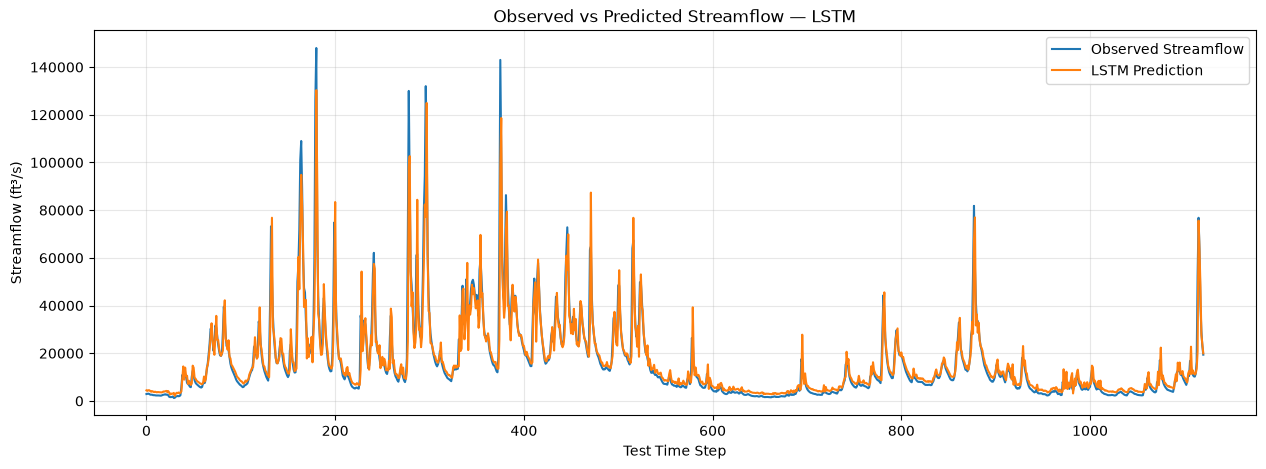

In [17]:
plt.figure(figsize=(15, 5))

plt.plot(y_test_actual, label="Observed Streamflow")
plt.plot(y_pred, label="LSTM Prediction")

plt.title("Observed vs Predicted Streamflow — LSTM")
plt.xlabel("Test Time Step")
plt.ylabel("Streamflow (ft³/s)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 15. Evaluate LSTM Performance

Model performance is evaluated using four metrics:

- **RMSE** — Root Mean Squared Error
- **MAE** — Mean Absolute Error
- **R²** — Coefficient of Determination
- **NSE** — Nash-Sutcliffe Efficiency

Lower RMSE and MAE indicate smaller prediction errors, while R² and NSE
values closer to 1 indicate better predictive performance.

In [18]:
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae = mean_absolute_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

observed = y_test_actual.flatten()
predicted = y_pred.flatten()

nse = 1 - (
    np.sum((observed - predicted) ** 2)
    /
    np.sum((observed - np.mean(observed)) ** 2)
)

print("LSTM PERFORMANCE")
print("---------------------------")
print(f"RMSE : {rmse:.2f} ft³/s")
print(f"MAE  : {mae:.2f} ft³/s")
print(f"R²   : {r2:.4f}")
print(f"NSE  : {nse:.4f}")

LSTM PERFORMANCE
---------------------------
RMSE : 5954.13 ft³/s
MAE  : 3045.41 ft³/s
R²   : 0.8895
NSE  : 0.8895


## 16. Persistence Baseline

A persistence model is used as a simple benchmark for evaluating the LSTM.

The persistence model assumes that the streamflow at the next time step
will be equal to the most recently observed streamflow.

This provides a baseline for determining whether the LSTM offers an
improvement over a simple forecasting strategy.

In [19]:
# Last value in every 30-day input window
persistence_scaled = X_test[:, -1, 0].reshape(-1, 1)

# Convert back to original streamflow units
persistence_pred = scaler.inverse_transform(persistence_scaled)

persistence_rmse = np.sqrt(
    mean_squared_error(y_test_actual, persistence_pred)
)

persistence_mae = mean_absolute_error(
    y_test_actual,
    persistence_pred
)

persistence_r2 = r2_score(
    y_test_actual,
    persistence_pred
)

persistence_observed = y_test_actual.flatten()
persistence_prediction = persistence_pred.flatten()

persistence_nse = 1 - (
    np.sum(
        (persistence_observed - persistence_prediction) ** 2
    )
    /
    np.sum(
        (persistence_observed - np.mean(persistence_observed)) ** 2
    )
)

print("PERSISTENCE BASELINE")
print("---------------------------")
print(f"RMSE : {persistence_rmse:.2f} ft³/s")
print(f"MAE  : {persistence_mae:.2f} ft³/s")
print(f"R²   : {persistence_r2:.4f}")
print(f"NSE  : {persistence_nse:.4f}")

PERSISTENCE BASELINE
---------------------------
RMSE : 8194.42 ft³/s
MAE  : 3490.35 ft³/s
R²   : 0.7908
NSE  : 0.7908


## 17. Bidirectional LSTM (BiLSTM)

A Bidirectional Long Short-Term Memory (BiLSTM) model is implemented
using the same 30-day input sequences used for the LSTM experiment.

Unlike a standard LSTM, which processes each historical sequence in one
direction, the BiLSTM learns representations by processing the known
input window in both forward and backward directions.

The target remains the streamflow of the following day, which is not
included in the input sequence.

In [20]:
bilstm_model = Sequential([
    Bidirectional(
        LSTM(64),
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),
    Dense(1)
])

bilstm_model.compile(
    optimizer="adam",
    loss="mse"
)

bilstm_model.summary()

c:\Users\karthik\Documents\kantamal-streamflow-forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:110: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,921 (132.50 KB)

 Trainable params: 33,921 (132.50 KB)

 Non-trainable params: 0 (0.00 B)

## 18. Train the BiLSTM Model

The BiLSTM is trained using the same training and validation datasets,
sequence length, batch size, and number of epochs as the LSTM.

Keeping the experimental settings consistent enables a fairer comparison
between the two architectures.

In [21]:
bilstm_history = bilstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    shuffle=False,
    verbose=1
)

Epoch 1/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0039 - val_loss: 0.0013
Epoch 2/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0028 - val_loss: 9.3684e-04
Epoch 3/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0022 - val_loss: 6.9245e-04
Epoch 4/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0018 - val_loss: 5.8069e-04
Epoch 5/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0015 - val_loss: 5.0009e-04
Epoch 6/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0012 - val_loss: 5.8752e-04
Epoch 7/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0012 - val_loss: 4.9897e-04
Epoch 8/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0011 - val_loss: 4.4206e-04
Epoch 9/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0011 - val_loss: 4.1545e-04
Epoch 10/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0010 - val_loss: 4.0180e-04
Epoch 11/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0010 - val_loss: 3.9348e-04
Epoch

## 19. Evaluate BiLSTM Performance

The trained BiLSTM is evaluated on the same unseen test period used for
the LSTM and persistence baseline.

In [22]:
bilstm_pred_scaled = bilstm_model.predict(X_test)

bilstm_pred = scaler.inverse_transform(bilstm_pred_scaled)

bilstm_rmse = np.sqrt(
    mean_squared_error(y_test_actual, bilstm_pred)
)

bilstm_mae = mean_absolute_error(
    y_test_actual, bilstm_pred
)

bilstm_r2 = r2_score(
    y_test_actual, bilstm_pred
)

bilstm_prediction = bilstm_pred.flatten()

bilstm_nse = 1 - (
    np.sum((observed - bilstm_prediction) ** 2)
    /
    np.sum((observed - np.mean(observed)) ** 2)
)

print("BiLSTM PERFORMANCE")
print("---------------------------")
print(f"RMSE : {bilstm_rmse:.2f} ft³/s")
print(f"MAE  : {bilstm_mae:.2f} ft³/s")
print(f"R²   : {bilstm_r2:.4f}")
print(f"NSE  : {bilstm_nse:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
BiLSTM PERFORMANCE
---------------------------
RMSE : 5951.40 ft³/s
MAE  : 3105.21 ft³/s
R²   : 0.8896
NSE  : 0.8896


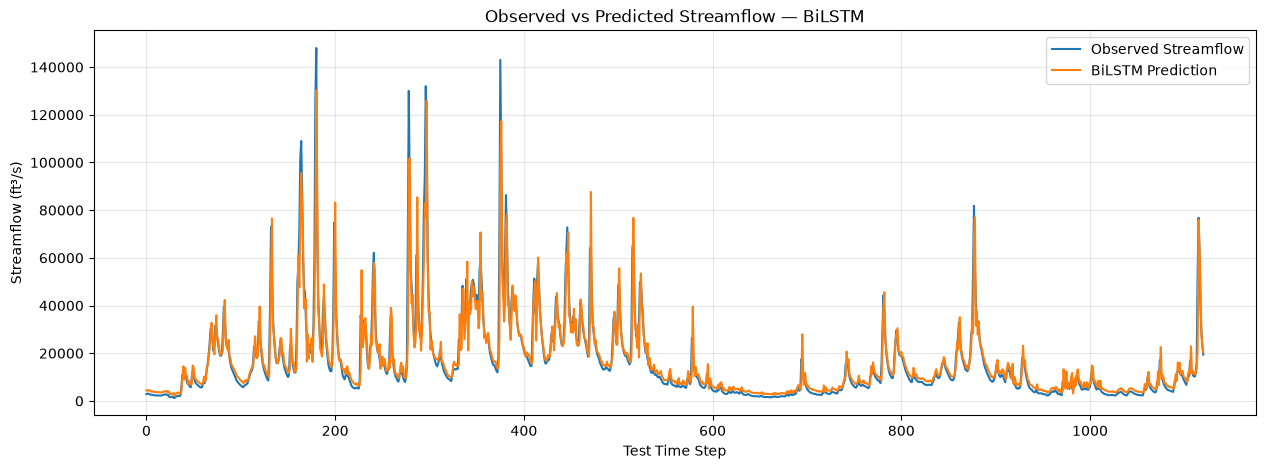

In [23]:
plt.figure(figsize=(15, 5))

plt.plot(y_test_actual, label="Observed Streamflow")
plt.plot(bilstm_pred, label="BiLSTM Prediction")

plt.title("Observed vs Predicted Streamflow — BiLSTM")
plt.xlabel("Test Time Step")
plt.ylabel("Streamflow (ft³/s)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 20. Transformer Model

A Transformer-based model is implemented as the third deep-learning
architecture for one-step-ahead streamflow forecasting.

Unlike recurrent models such as LSTM and BiLSTM, the Transformer uses
self-attention to learn relationships between different positions within
the historical input sequence.

The same 30-day input window and chronological train-validation-test
datasets are retained for comparison.

## 21. Build the Transformer Model

A compact Transformer encoder is constructed using multi-head
self-attention, residual connections, layer normalization, and a
feed-forward neural network.

A small architecture is used because the sample dataset is univariate
and relatively limited in size.

In [24]:
inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))

# Self-attention
attention_output = MultiHeadAttention(
    num_heads=2,
    key_dim=16
)(inputs, inputs)

attention_output = Dropout(0.1)(attention_output)

# Residual connection + normalization
x = LayerNormalization(epsilon=1e-6)(
    inputs + attention_output
)

# Feed-forward network
ffn = Dense(32, activation="relu")(x)
ffn = Dense(1)(ffn)
ffn = Dropout(0.1)(ffn)

# Second residual connection
x = LayerNormalization(epsilon=1e-6)(
    x + ffn
)

# Convert sequence representation into one vector
x = GlobalAveragePooling1D()(x)

x = Dense(32, activation="relu")(x)

outputs = Dense(1)(x)

transformer_model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs
)

transformer_model.compile(
    optimizer="adam",
    loss="mse"
)

transformer_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 1)     │        225 │ input_layer_2[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 1)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 1)     │          0 │ input_layer_2[0]… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 1)     │          2 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 30, 32)    │         64 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 30, 1)     │         33 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 1)     │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 1)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 1)     │          2 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1)         │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │         64 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         33 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 423 (1.65 KB)

 Trainable params: 423 (1.65 KB)

 Non-trainable params: 0 (0.00 B)

## 22. Train the Transformer Model

The Transformer is trained using the same chronological training and
validation datasets used for LSTM and BiLSTM.

The same number of epochs and batch size are retained to provide a
consistent initial comparison between the architectures.

In [25]:

transformer_history = transformer_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    shuffle=False,
    verbose=1
)

Epoch 1/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0071 - val_loss: 0.0029
Epoch 2/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0065 - val_loss: 0.0030
Epoch 3/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0065 - val_loss: 0.0030
Epoch 4/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0065 - val_loss: 0.0030
Epoch 5/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0065 - val_loss: 0.0030
Epoch 6/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0065 - val_loss: 0.0030
Epoch 7/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0065 - val_loss: 0.0030
Epoch 8/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0065 - val_loss: 0.0030
Epoch 9/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0065 - val_loss: 0.0030
Epoch 10/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0065 - val_loss: 0.0030
Epoch 11/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0065 - val_loss: 0.0030
Epoch 12/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

## 23. Evaluate Transformer Performance

The trained Transformer is evaluated on the same unseen test period
used for the persistence, LSTM, and BiLSTM experiments.

In [26]:
transformer_pred_scaled = transformer_model.predict(X_test)

transformer_pred = scaler.inverse_transform(
    transformer_pred_scaled
)

transformer_rmse = np.sqrt(
    mean_squared_error(y_test_actual, transformer_pred)
)

transformer_mae = mean_absolute_error(
    y_test_actual, transformer_pred
)

transformer_r2 = r2_score(
    y_test_actual, transformer_pred
)

transformer_prediction = transformer_pred.flatten()

transformer_nse = 1 - (
    np.sum((observed - transformer_prediction) ** 2)
    /
    np.sum((observed - np.mean(observed)) ** 2)
)

print("TRANSFORMER PERFORMANCE")
print("---------------------------")
print(f"RMSE : {transformer_rmse:.2f} ft³/s")
print(f"MAE  : {transformer_mae:.2f} ft³/s")
print(f"R²   : {transformer_r2:.4f}")
print(f"NSE  : {transformer_nse:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
TRANSFORMER PERFORMANCE
---------------------------
RMSE : 18537.82 ft³/s
MAE  : 11274.94 ft³/s
R²   : -0.0708
NSE  : -0.0708


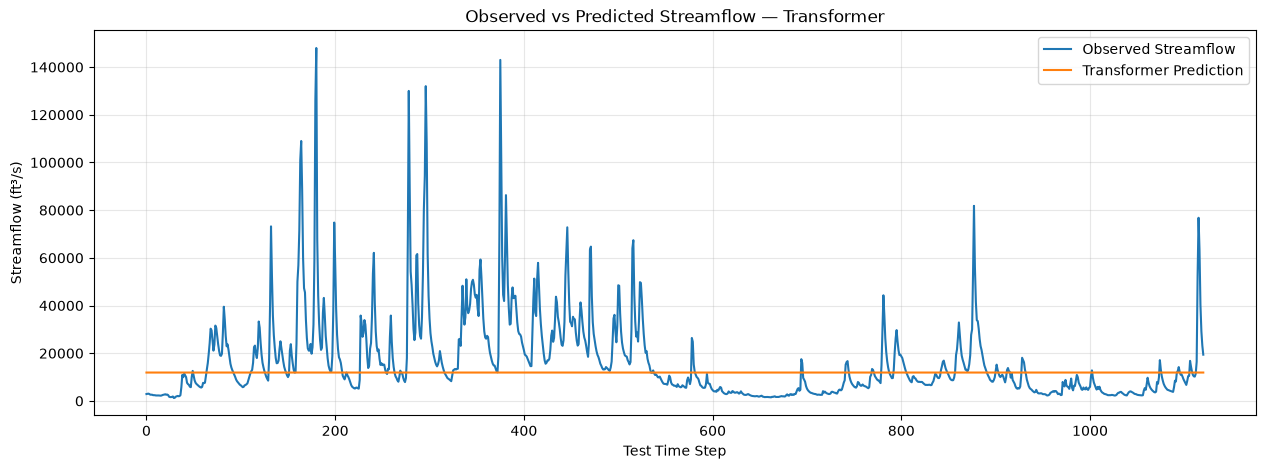

In [27]:
plt.figure(figsize=(15, 5))

plt.plot(
    y_test_actual,
    label="Observed Streamflow"
)

plt.plot(
    transformer_pred,
    label="Transformer Prediction"
)

plt.title("Observed vs Predicted Streamflow — Transformer")
plt.xlabel("Test Time Step")
plt.ylabel("Streamflow (ft³/s)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 24. Improved Transformer with Positional Encoding

The initial Transformer produced nearly constant predictions and failed
to capture streamflow variability.

A possible limitation is the absence of explicit positional information.
Unlike recurrent neural networks, self-attention does not inherently
represent the chronological order of observations.

An improved Transformer is therefore developed using:

- feature projection to a higher-dimensional representation
- learnable positional embeddings
- multi-head self-attention
- residual connections
- layer normalization
- feed-forward layers

In [31]:
SEQ_LEN = X_train.shape[1]
D_MODEL = 32

inputs = tf.keras.Input(
    shape=(SEQ_LEN, X_train.shape[2])
)

# Project streamflow from 1 feature -> 32-dimensional representation
x = tf.keras.layers.Dense(D_MODEL)(inputs)

# Learnable positional information
positions = tf.range(start=0, limit=SEQ_LEN, delta=1)

position_embedding = tf.keras.layers.Embedding(
    input_dim=SEQ_LEN,
    output_dim=D_MODEL
)(positions)

x = x + position_embedding
attention = tf.keras.layers.MultiHeadAttention(
    num_heads=4,
    key_dim=8
)(x, x)



attention = tf.keras.layers.Dropout(0.1)(attention)

x = tf.keras.layers.LayerNormalization(
    epsilon=1e-6
)(x + attention)

# Feed-forward network
ffn = tf.keras.layers.Dense(
    64,
    activation="relu"
)(x)

ffn = tf.keras.layers.Dense(
    D_MODEL
)(ffn)

ffn = tf.keras.layers.Dropout(0.1)(ffn)

x = tf.keras.layers.LayerNormalization(
    epsilon=1e-6
)(x + ffn)
x = tf.keras.layers.Flatten()(x)

x = tf.keras.layers.Dense(
    64,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(0.1)(x)

outputs = tf.keras.layers.Dense(1)(x)

transformer_v2 = tf.keras.Model(
    inputs=inputs,
    outputs=outputs
)

transformer_v2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse"
)

transformer_v2.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 30, 32)    │         64 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 30, 32)    │          0 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 32)    │      4,224 │ add_9[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_9[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 30, 32)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 30, 32)    │          0 │ add_9[0][0],      │
│                     │                   │            │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 32)    │         64 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 30, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 30, 32)    │      2,080 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 30, 32)    │          0 │ dense_15[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 30, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 32)    │         64 │ add_11[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 960)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 64)        │     61,504 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 64)        │          0 │ dense_16[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 1)         │         65 │ dropout_12[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 70,177 (274.13 KB)

 Trainable params: 70,177 (274.13 KB)

 Non-trainable params: 0 (0.00 B)

## 25. Train Improved Transformer

The improved Transformer is trained using the same chronological
training and validation datasets used for the previous models.

In [32]:
transformer_v2_history = transformer_v2.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    shuffle=False,
    verbose=1
)

Epoch 1/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.2097 - val_loss: 0.0027
Epoch 2/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0070 - val_loss: 0.0020
Epoch 3/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0060 - val_loss: 0.0019
Epoch 4/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0053 - val_loss: 0.0017
Epoch 5/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0048 - val_loss: 0.0015
Epoch 6/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0046 - val_loss: 0.0014
Epoch 7/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0042 - val_loss: 0.0013
Epoch 8/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0039 - val_loss: 0.0011
Epoch 9/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0036 - val_loss: 0.0011
Epoch 10/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0034 - val_loss: 9.8214e-04
Epoch 11/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0033 - val_loss: 9.2828e-04
Epoch 12/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 

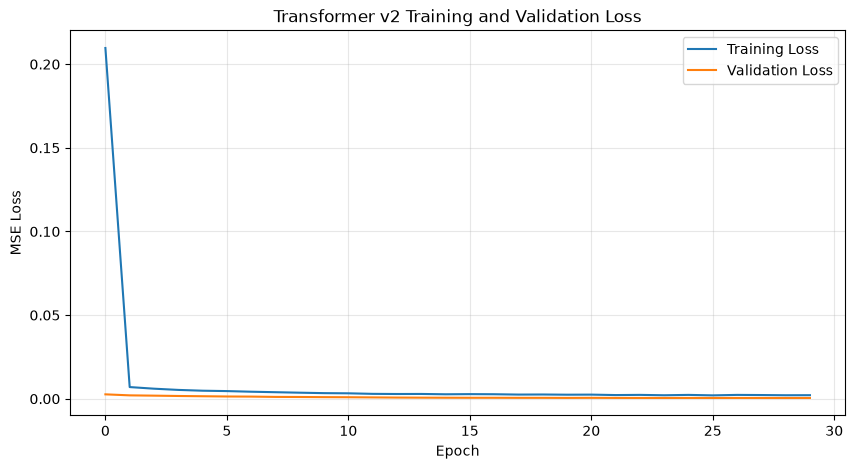

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    transformer_v2_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    transformer_v2_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Transformer v2 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [34]:
transformer_v2_scaled = transformer_v2.predict(X_test)

transformer_v2_pred = scaler.inverse_transform(
    transformer_v2_scaled
)

transformer_v2_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        transformer_v2_pred
    )
)

transformer_v2_mae = mean_absolute_error(
    y_test_actual,
    transformer_v2_pred
)

transformer_v2_r2 = r2_score(
    y_test_actual,
    transformer_v2_pred
)

transformer_v2_prediction = transformer_v2_pred.flatten()

transformer_v2_nse = 1 - (
    np.sum(
        (observed - transformer_v2_prediction) ** 2
    )
    /
    np.sum(
        (observed - np.mean(observed)) ** 2
    )
)

print("TRANSFORMER V2 PERFORMANCE")
print("---------------------------")
print(f"RMSE : {transformer_v2_rmse:.2f} ft³/s")
print(f"MAE  : {transformer_v2_mae:.2f} ft³/s")
print(f"R²   : {transformer_v2_r2:.4f}")
print(f"NSE  : {transformer_v2_nse:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
TRANSFORMER V2 PERFORMANCE
---------------------------
RMSE : 7925.38 ft³/s
MAE  : 4054.10 ft³/s
R²   : 0.8043
NSE  : 0.8043


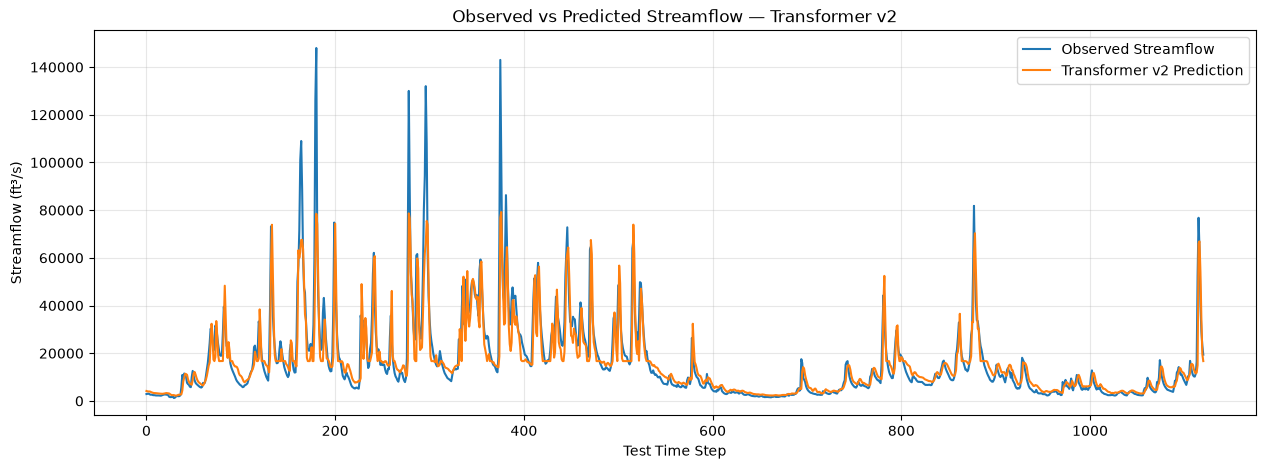

In [35]:
plt.figure(figsize=(15, 5))

plt.plot(
    y_test_actual,
    label="Observed Streamflow"
)

plt.plot(
    transformer_v2_pred,
    label="Transformer v2 Prediction"
)

plt.title(
    "Observed vs Predicted Streamflow — Transformer v2"
)

plt.xlabel("Test Time Step")
plt.ylabel("Streamflow (ft³/s)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 26. Model Comparison

The persistence baseline, LSTM, BiLSTM, and Transformer architectures are
compared using the same unseen test period.

The initial Transformer without explicit positional information failed to
represent the temporal dynamics effectively. Adding positional embeddings
substantially improved Transformer performance.

The recurrent LSTM and BiLSTM models achieved stronger performance on this
univariate daily streamflow forecasting experiment.

In [36]:
results = pd.DataFrame({
    "Model": [
        "Persistence",
        "LSTM",
        "BiLSTM",
        "Transformer v1",
        "Transformer v2"
    ],
    "RMSE": [
        persistence_rmse,
        rmse,
        bilstm_rmse,
        transformer_rmse,
        transformer_v2_rmse
    ],
    "MAE": [
        persistence_mae,
        mae,
        bilstm_mae,
        transformer_mae,
        transformer_v2_mae
    ],
    "R2": [
        persistence_r2,
        r2,
        bilstm_r2,
        transformer_r2,
        transformer_v2_r2
    ],
    "NSE": [
        persistence_nse,
        nse,
        bilstm_nse,
        transformer_nse,
        transformer_v2_nse
    ]
})

results.round(4)

,Model,RMSE,MAE,R2,NSE
0,Persistence,8194.4191,3490.3479,0.7908,0.7908
1,LSTM,5954.1262,3045.4087,0.8895,0.8895
2,BiLSTM,5951.4034,3105.2098,0.8896,0.8896
3,Transformer v1,18537.8228,11274.9387,-0.0708,-0.0708
4,Transformer v2,7925.3799,4054.1033,0.8043,0.8043


## 27. Conclusion

This experiment established a complete one-step-ahead streamflow forecasting
pipeline using a real daily discharge time series.

A persistence model was used as a non-deep-learning benchmark. Both LSTM
and BiLSTM improved substantially over this baseline, demonstrating that
the recurrent models learned useful temporal relationships within the
30-day historical streamflow sequence.

The initial Transformer performed poorly and produced nearly constant
predictions. After introducing feature projection and learnable positional
information, Transformer performance improved substantially, demonstrating
the importance of representing temporal order in attention-based forecasting.

For this univariate experiment, LSTM and BiLSTM produced similar overall
performance and were stronger than the tested Transformer configurations.

The next stage extends this workflow to the Kantamal catchment using
hydrological and meteorological variables such as streamflow, water level,
rainfall, and temperature.

In [37]:
results.to_csv(
    "../results/sample_model_comparison.csv",
    index=False
)

In [38]:
file_path = "../data/sample/chrono_data.csv"

df = pd.read_csv(file_path)

df.head()

,id,approval_status,last_modified,monitoring_location_id,parameter_code,qualifier,statistic_id,time,time_series_id,unit_of_measure,value,x,y
0,26fb66a3-4cd2-4309-b792-a0b4f5e19b9f,Approved,2025-03-11T06:29:47.694332+00:00,USGS-01646500,60,NaN,3,1930-03-01,2cf409b0d9694c01828f5d4ff14586a5,ft^3/s,9500,-77.127639,38.949778
1,ab9b1e1b-210b-411d-a91d-cbc4469cf32e,Approved,2025-03-11T06:29:47.694332+00:00,USGS-01646500,60,NaN,3,1930-03-02,2cf409b0d9694c01828f5d4ff14586a5,ft^3/s,9200,-77.127639,38.949778
2,0662afe3-fc1d-4537-a0de-ec7bfdf9bbe5,Approved,2025-03-11T06:29:47.694332+00:00,USGS-01646500,60,NaN,3,1930-03-03,2cf409b0d9694c01828f5d4ff14586a5,ft^3/s,8500,-77.127639,38.949778
3,0ca5e5fe-3238-48b4-a6b8-2aee5738c4ae,Approved,2025-03-11T06:29:47.694332+00:00,USGS-01646500,60,NaN,3,1930-03-04,2cf409b0d9694c01828f5d4ff14586a5,ft^3/s,8000,-77.127639,38.949778
4,1da76b31-60b1-476c-b0c8-2da94228250c,Approved,2025-03-11T06:29:47.694332+00:00,USGS-01646500,60,NaN,3,1930-03-05,2cf409b0d9694c01828f5d4ff14586a5,ft^3/s,7500,-77.127639,38.949778
